In [7]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import curve_fit
import os
import sys
import glob
from pathlib import Path

sys.path.append(os.path.abspath(".."))

from libs import fit_model as fm 
from libs import cal_vel as cv
from libs import displacement as dpm

plt.style.use('../libs/my_style.mplstyle')
style_colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

In [8]:
mypass = Path('/Volumes/data/Sasaki/MTSingleBeads')
#mypass = Path('/mnt/NAS-Ebanaru/Sasaki/MTSingleBeads')


folder = mypass / 'beads3um'

def make_corr_df(folder, lag_time_frames = 1):
    corr_list = []

    exp = 0

    for i in glob.glob(str(Path(folder) / "*" / "*")):
        if os.path.isfile(i):
            continue
        i=Path(i)
        beads = pd.read_csv(i/"beads_tracks.csv")
        corr = dpm.spatial_velocity_correlation(beads, lag_time_frames, scale=0.11, normalize=True)
        corr_dict = {'exp':[], 'corr':[]}
        corr_dict['exp'] = i.name
        corr_dict['corr'] = corr

        corr_list.append(pd.DataFrame(corr_dict))
        exp += 1

    corr_df = pd.concat(corr_list)

    return corr_df


def make_corr_df(folder, lag_time_frames=1):
    corr_list = []

    for i in glob.glob(str(Path(folder) / "*" / "*")):
        if os.path.isfile(i):
            continue
        
        i = Path(i)
        csv_path = i / "beads_tracks.csv"
        
        # csvファイルが存在しないフォルダをスキップする安全策を追加
        if not csv_path.exists():
            continue
            
        beads = pd.read_csv(csv_path)
        
        # dpm.spatial_velocity_correlationは DataFrame を返すようになりました
        corr_df_frame = dpm.spatial_velocity_correlation(beads, lag_time_frames, scale=0.11, normalize=True)
        
        if not corr_df_frame.empty:
            # 以降の処理との互換性のため 'correlation' 列を 'corr' にリネーム
            corr_df_frame = corr_df_frame.rename(columns={'correlation': 'corr'})
            # フォルダ名を 'exp' 列として追加
            corr_df_frame['exp'] = i.name
            corr_list.append(corr_df_frame)

    if not corr_list:
        return pd.DataFrame(columns=['frame', 'corr', 'exp'])

    corr_df = pd.concat(corr_list, ignore_index=True)

    return corr_df


corr06 = make_corr_df(mypass/'beads06um')
corr1 = make_corr_df(mypass/'beads1um')
corr3 = make_corr_df(mypass/'beads3um')
corr5 = make_corr_df(mypass/'beads5um')
corr7 = make_corr_df(mypass/'beads7um')

In [9]:
corr1

,frame,corr,exp
0,0,-0.165593,beads1um001_crop
1,1,-0.177233,beads1um001_crop
2,2,0.459077,beads1um001_crop
3,3,-0.152027,beads1um001_crop
4,4,0.147868,beads1um001_crop
...,...,...,...
1875,134,-0.067414,beads1um_crop
1876,135,-0.082019,beads1um_crop
1877,136,-0.035823,beads1um_crop
1878,137,-0.075978,beads1um_crop


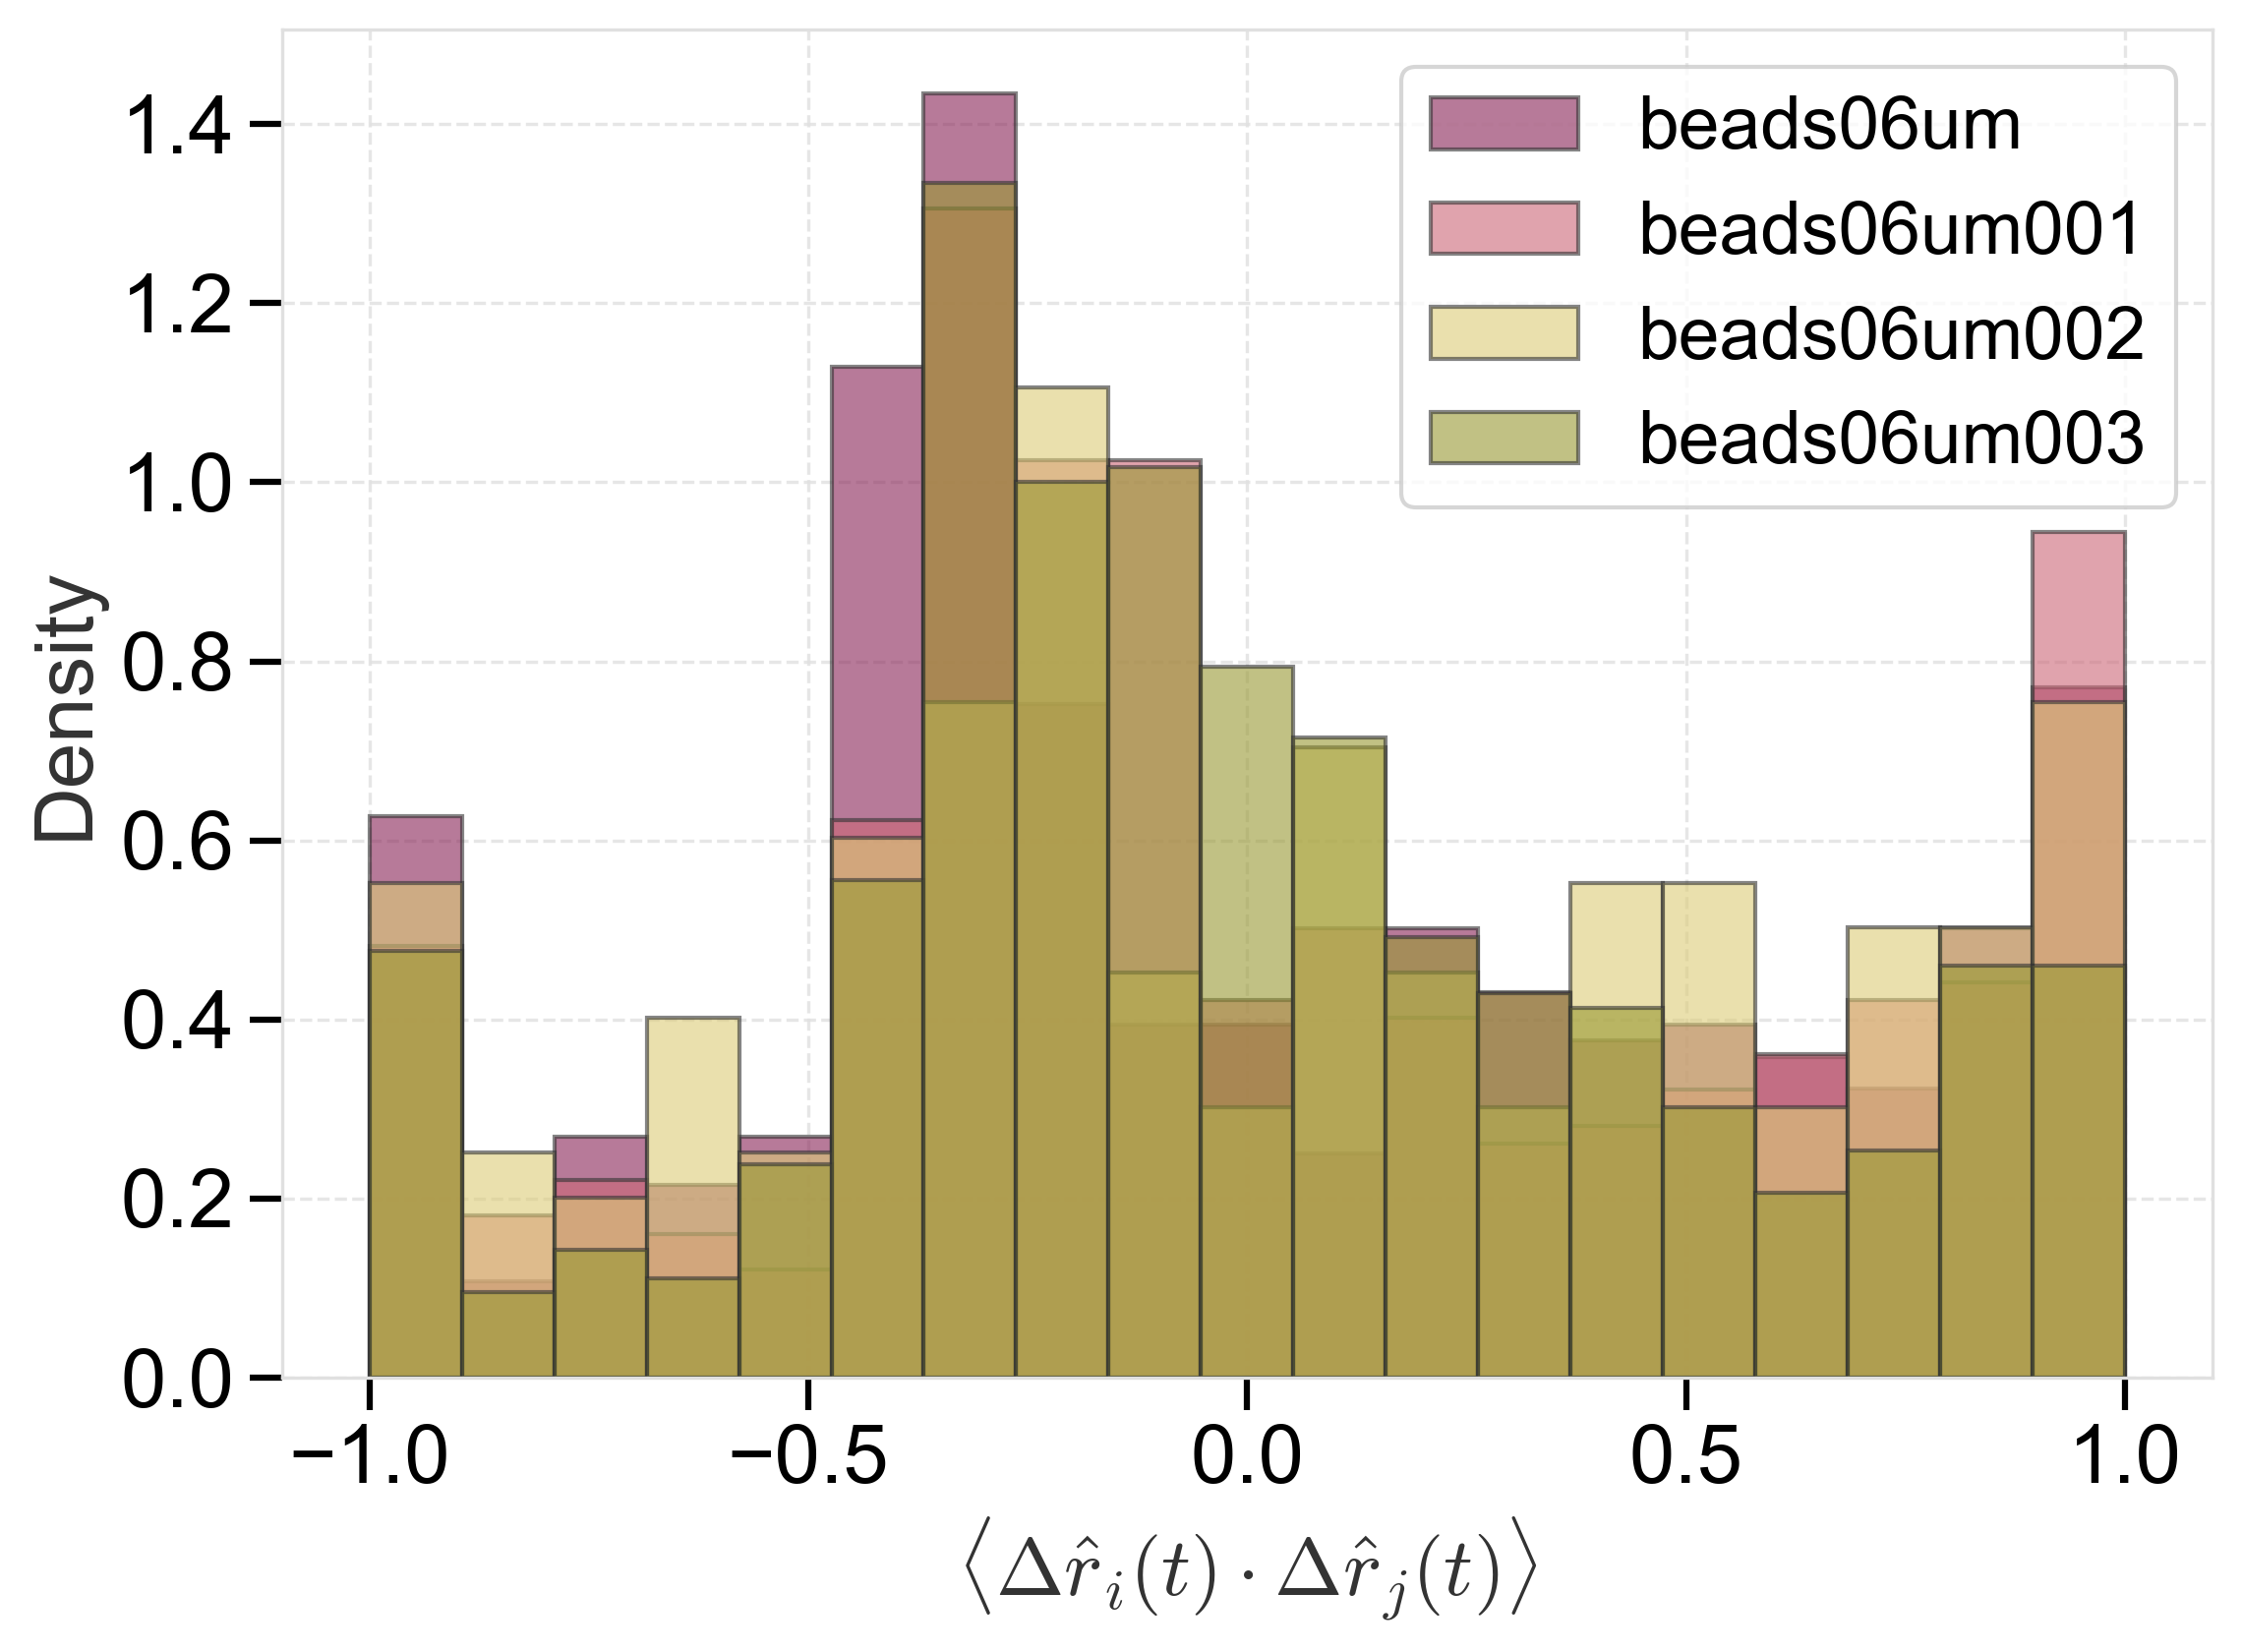

In [10]:
fig, ax = plt.subplots()

bins = np.linspace(-1,1, 20)

for exp, i in corr06.groupby('exp'):
    ax.hist(i['corr'], bins, label=exp, alpha =0.6, density = True, edgecolor ='#333333')

ax.legend()
ax.set(xlabel = "$\\langle \\Delta\\hat{r}_i(t) \cdot \\Delta\\hat{r}_j(t) \\rangle$", ylabel='Density')

fig.savefig(mypass/'figure'/'corr_beads06um.svg')

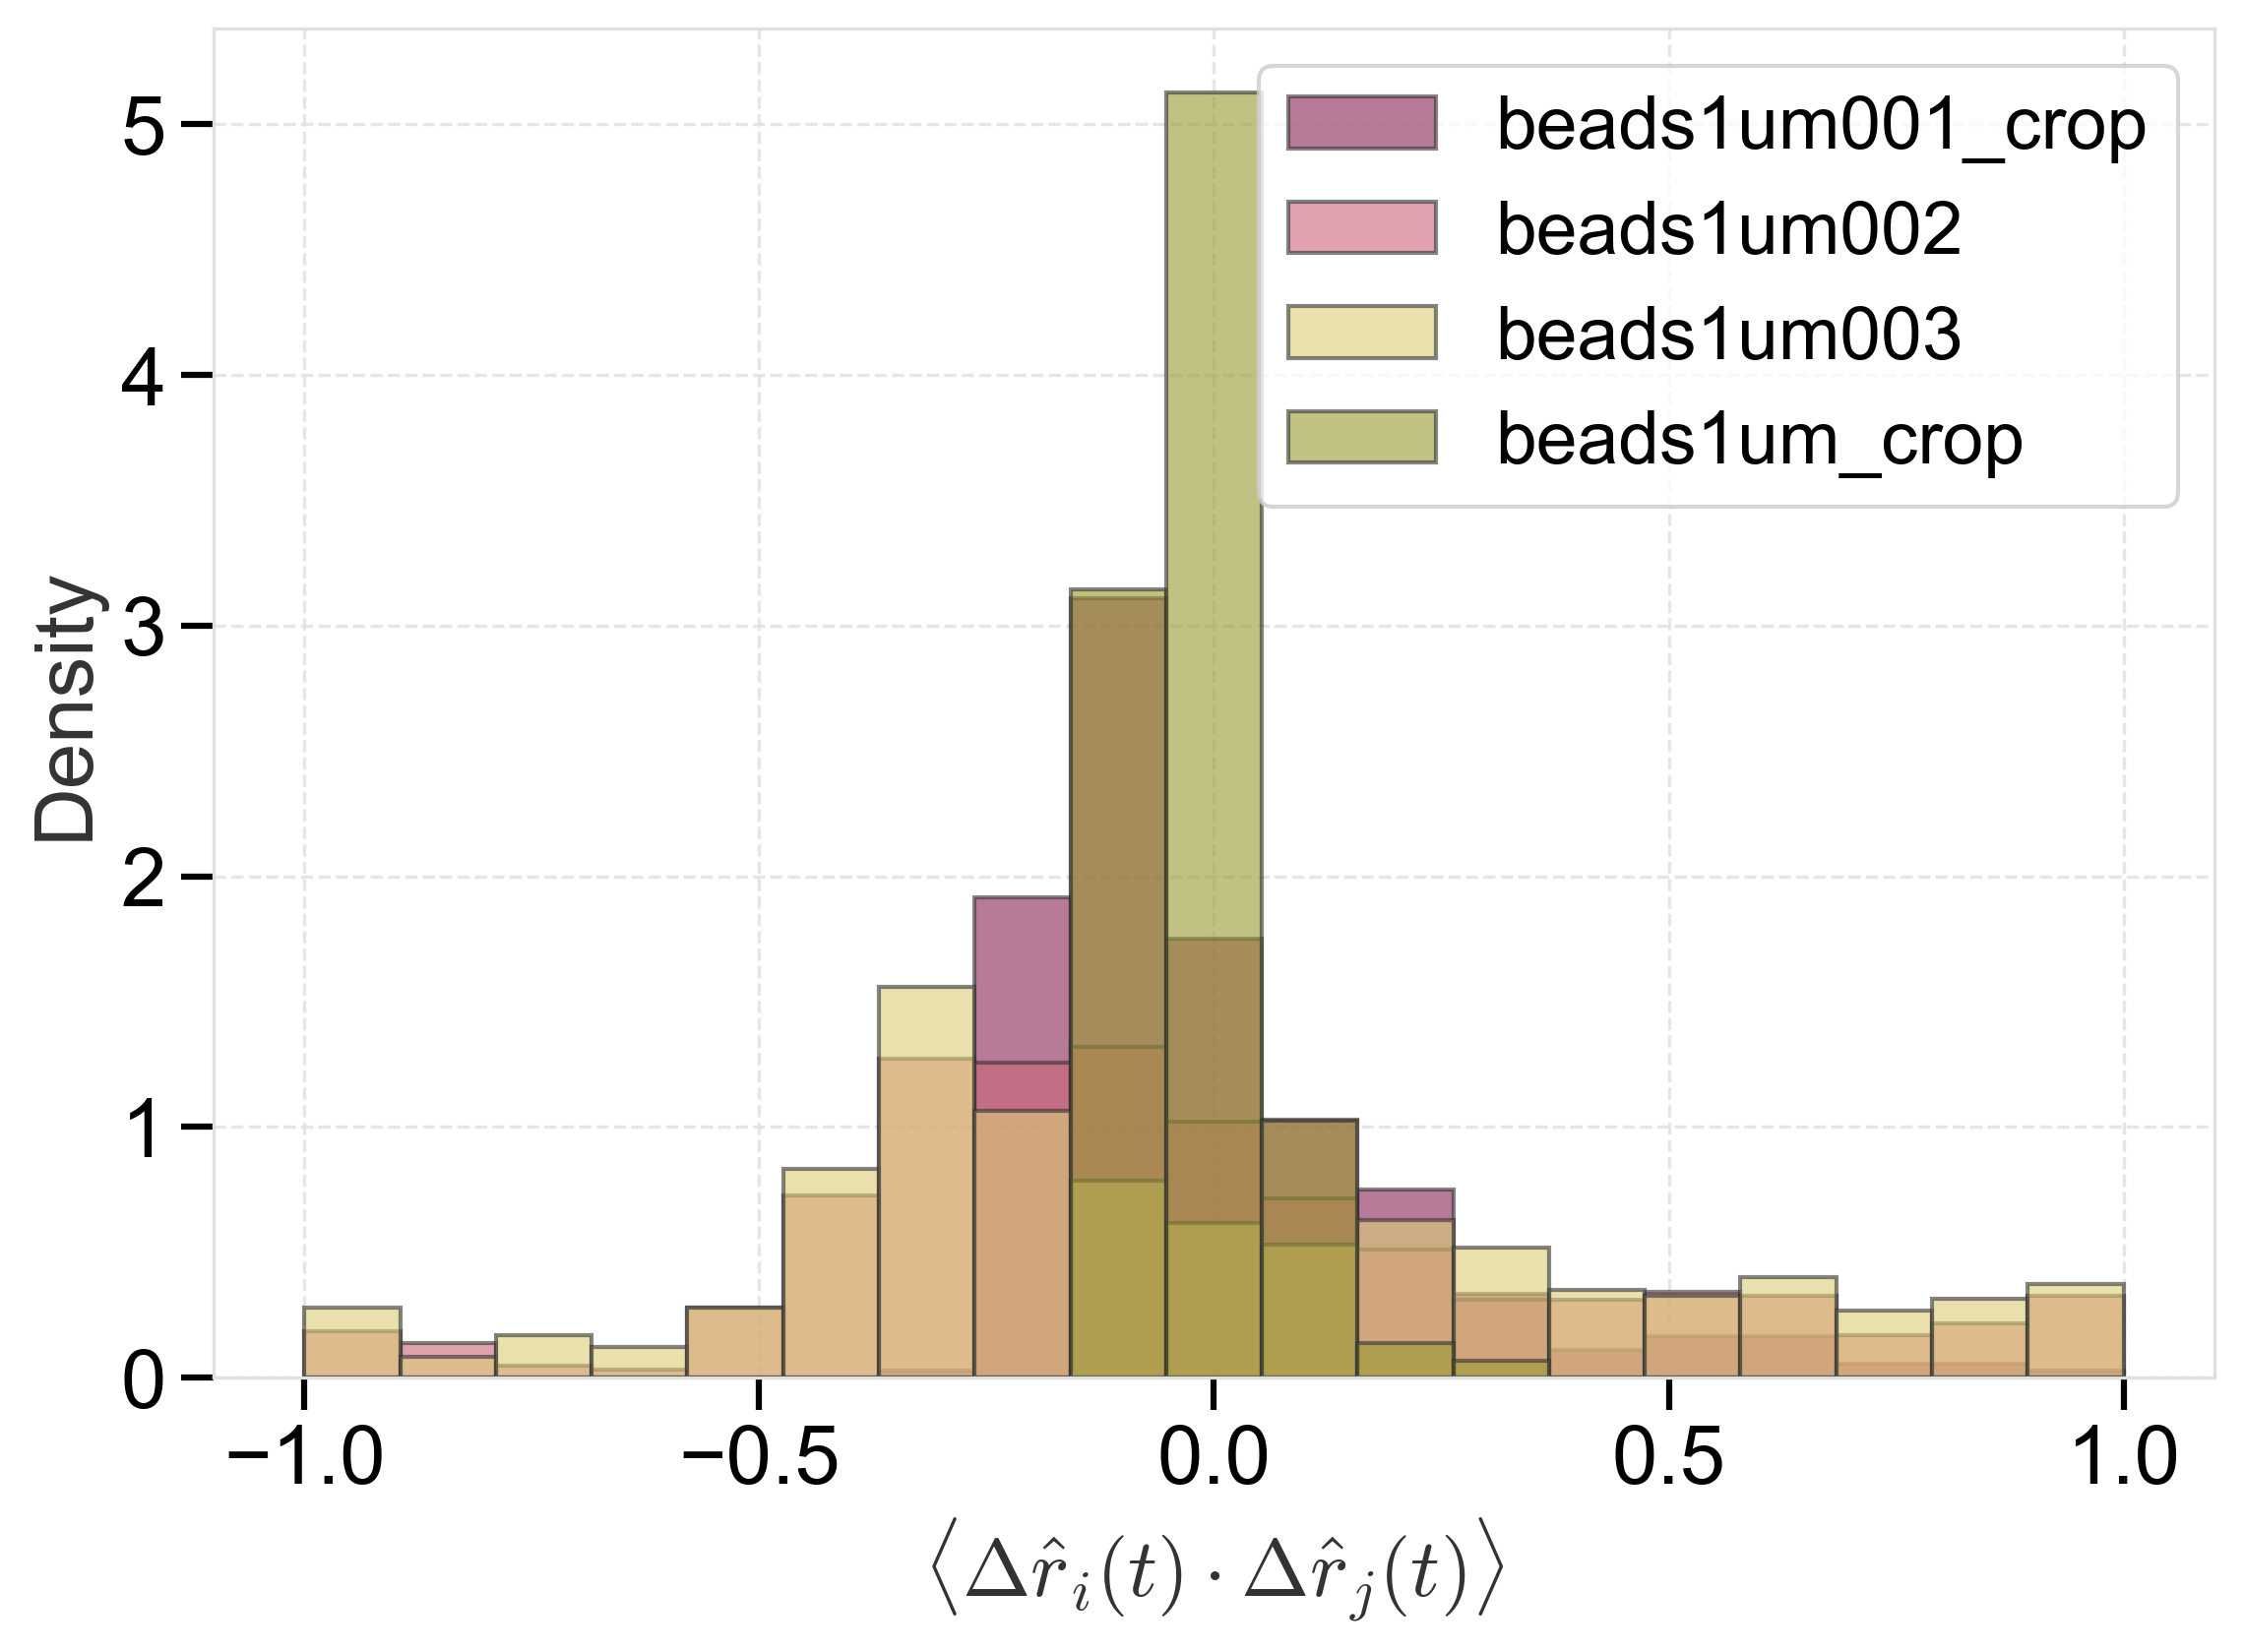

In [11]:
fig, ax = plt.subplots()

bins = np.linspace(-1,1, 20)

for exp, i in corr1.groupby('exp'):
    ax.hist(i['corr'], bins, label=exp, alpha =0.6, density = True, edgecolor ='#333333')

ax.legend()
ax.set(xlabel = "$\\langle \\Delta\\hat{r}_i(t) \cdot \\Delta\\hat{r}_j(t) \\rangle$", ylabel='Density')

fig.savefig(mypass/'figure'/'corr_beads1um.svg')

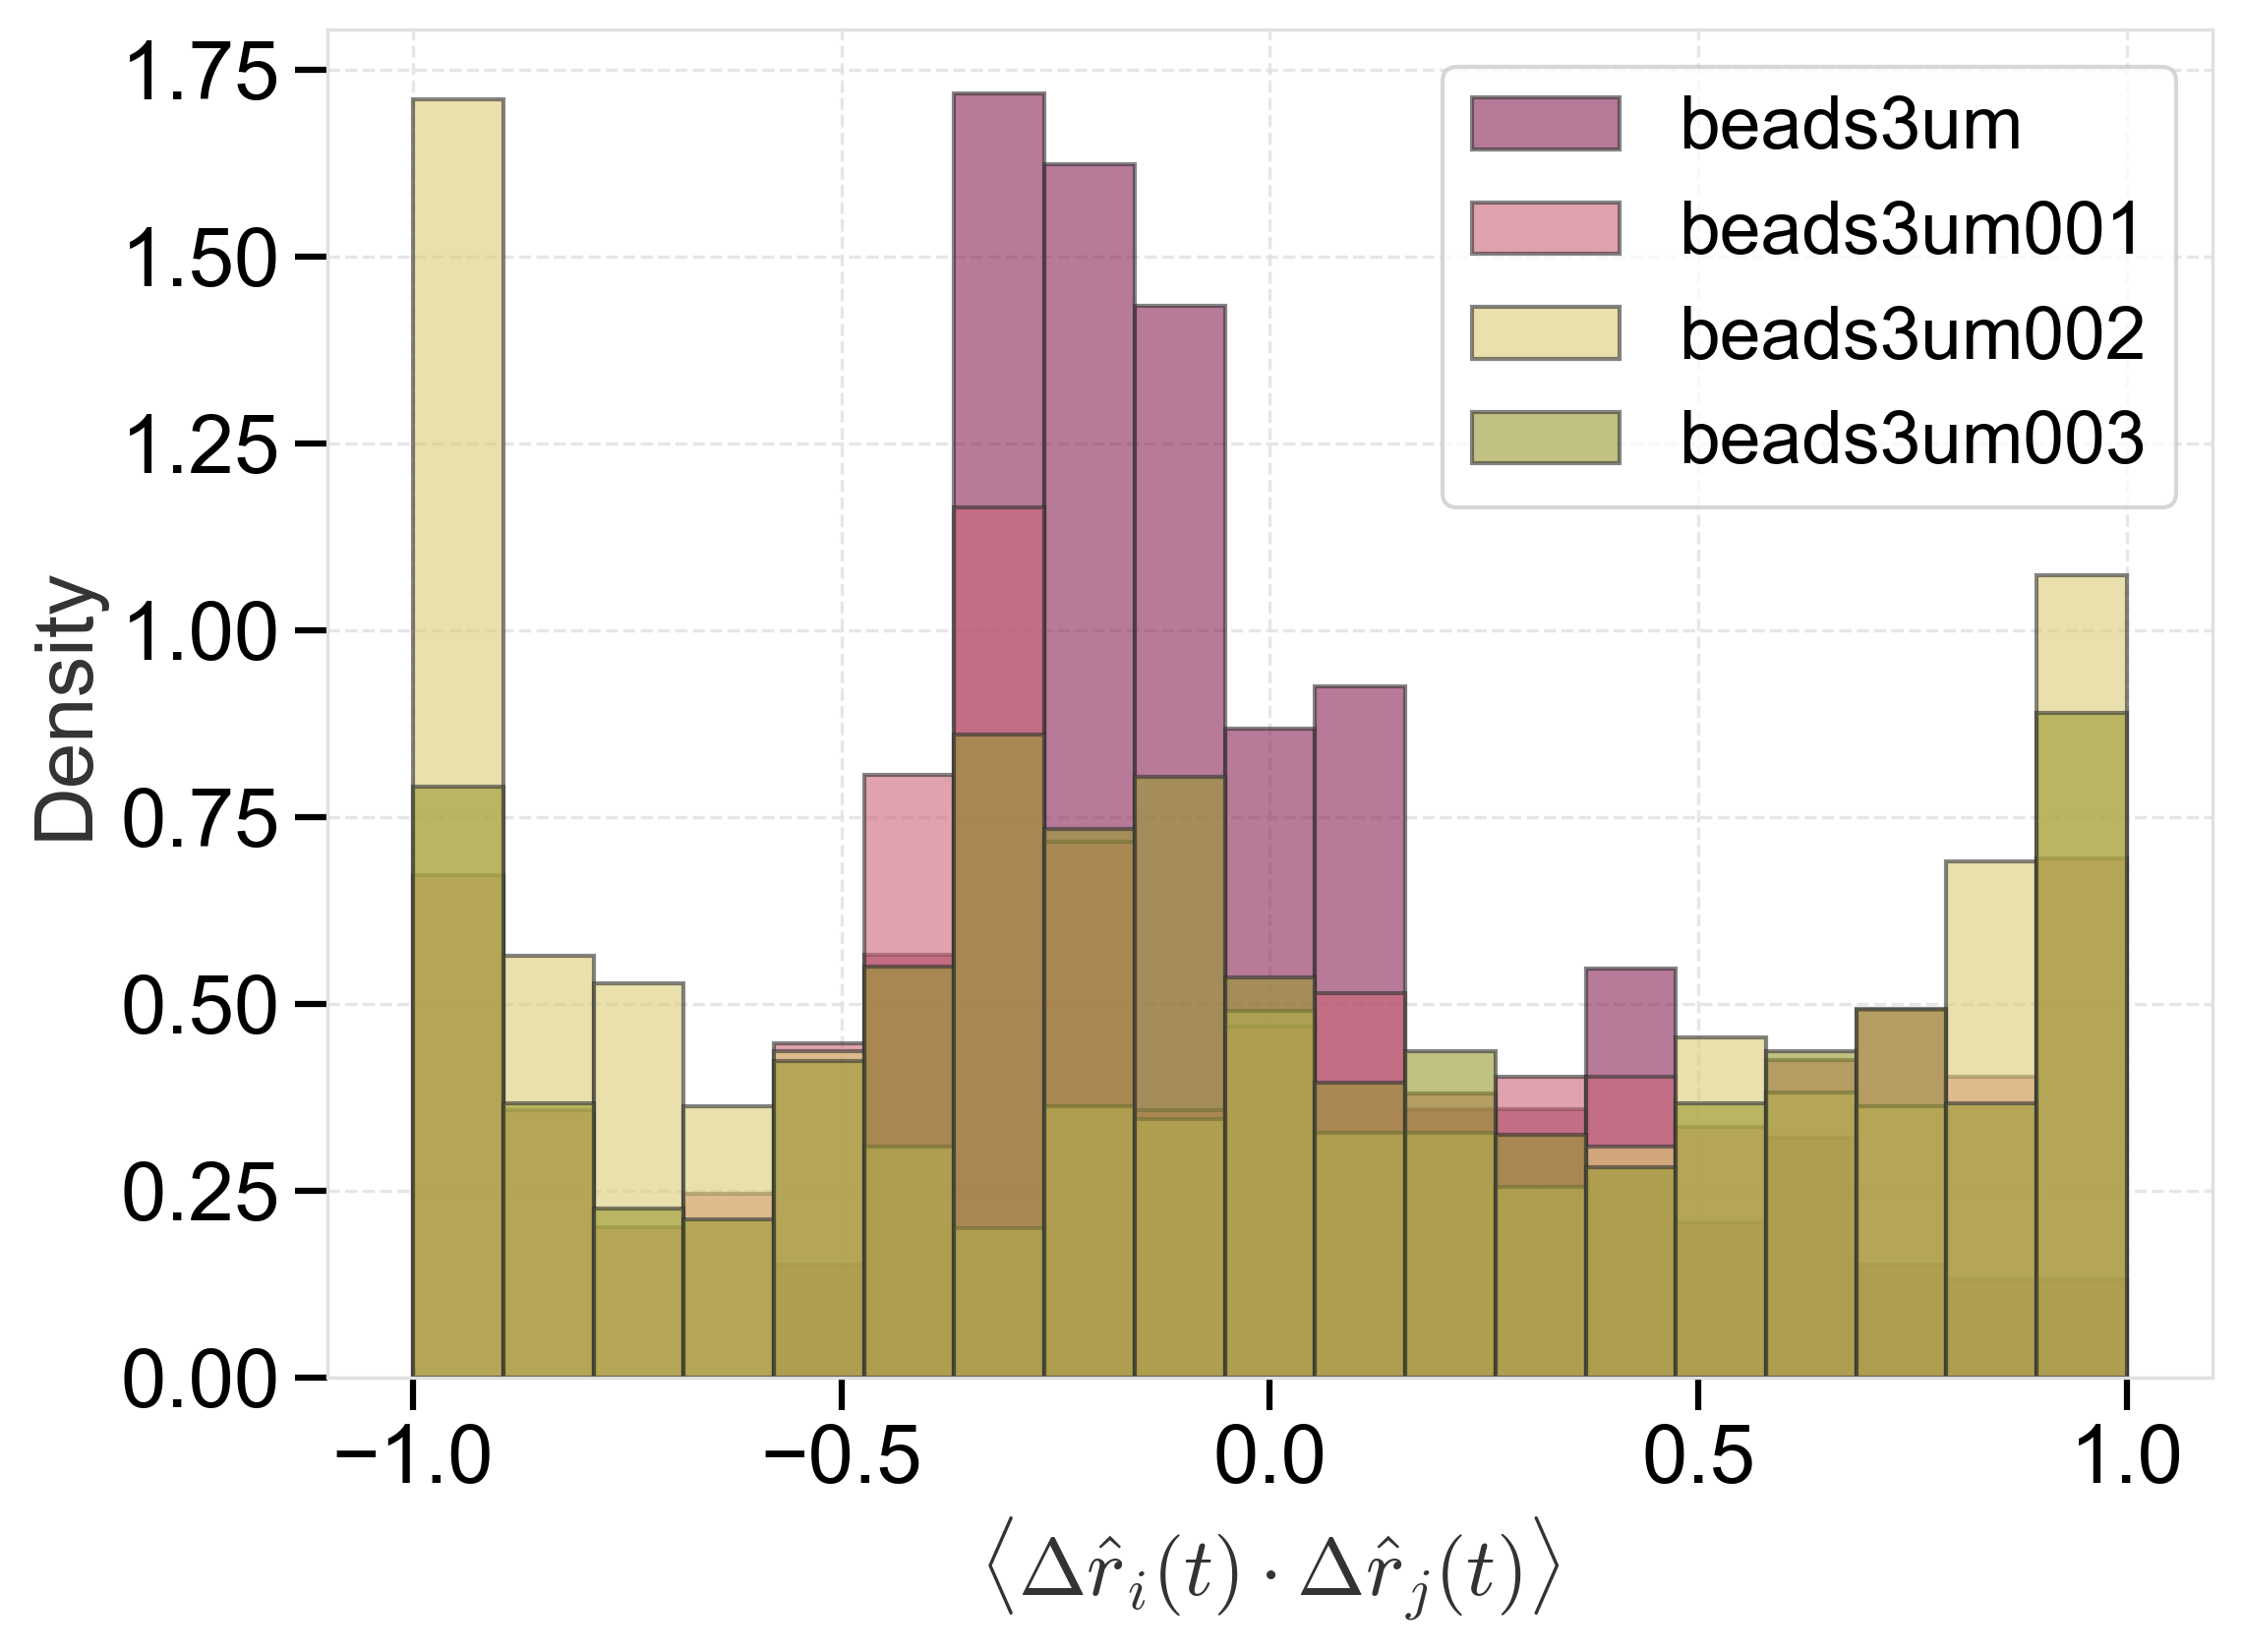

In [12]:
fig, ax = plt.subplots()

bins = np.linspace(-1,1, 20)

for exp, i in corr3.groupby('exp'):
    ax.hist(i['corr'], bins, label=exp, alpha =0.6, density = True, edgecolor ='#333333')

ax.legend()
ax.set(xlabel = "$\\langle \\Delta\\hat{r}_i(t) \cdot \\Delta\\hat{r}_j(t) \\rangle$", ylabel='Density')

fig.savefig(mypass/'figure'/'corr_beads3um.svg')

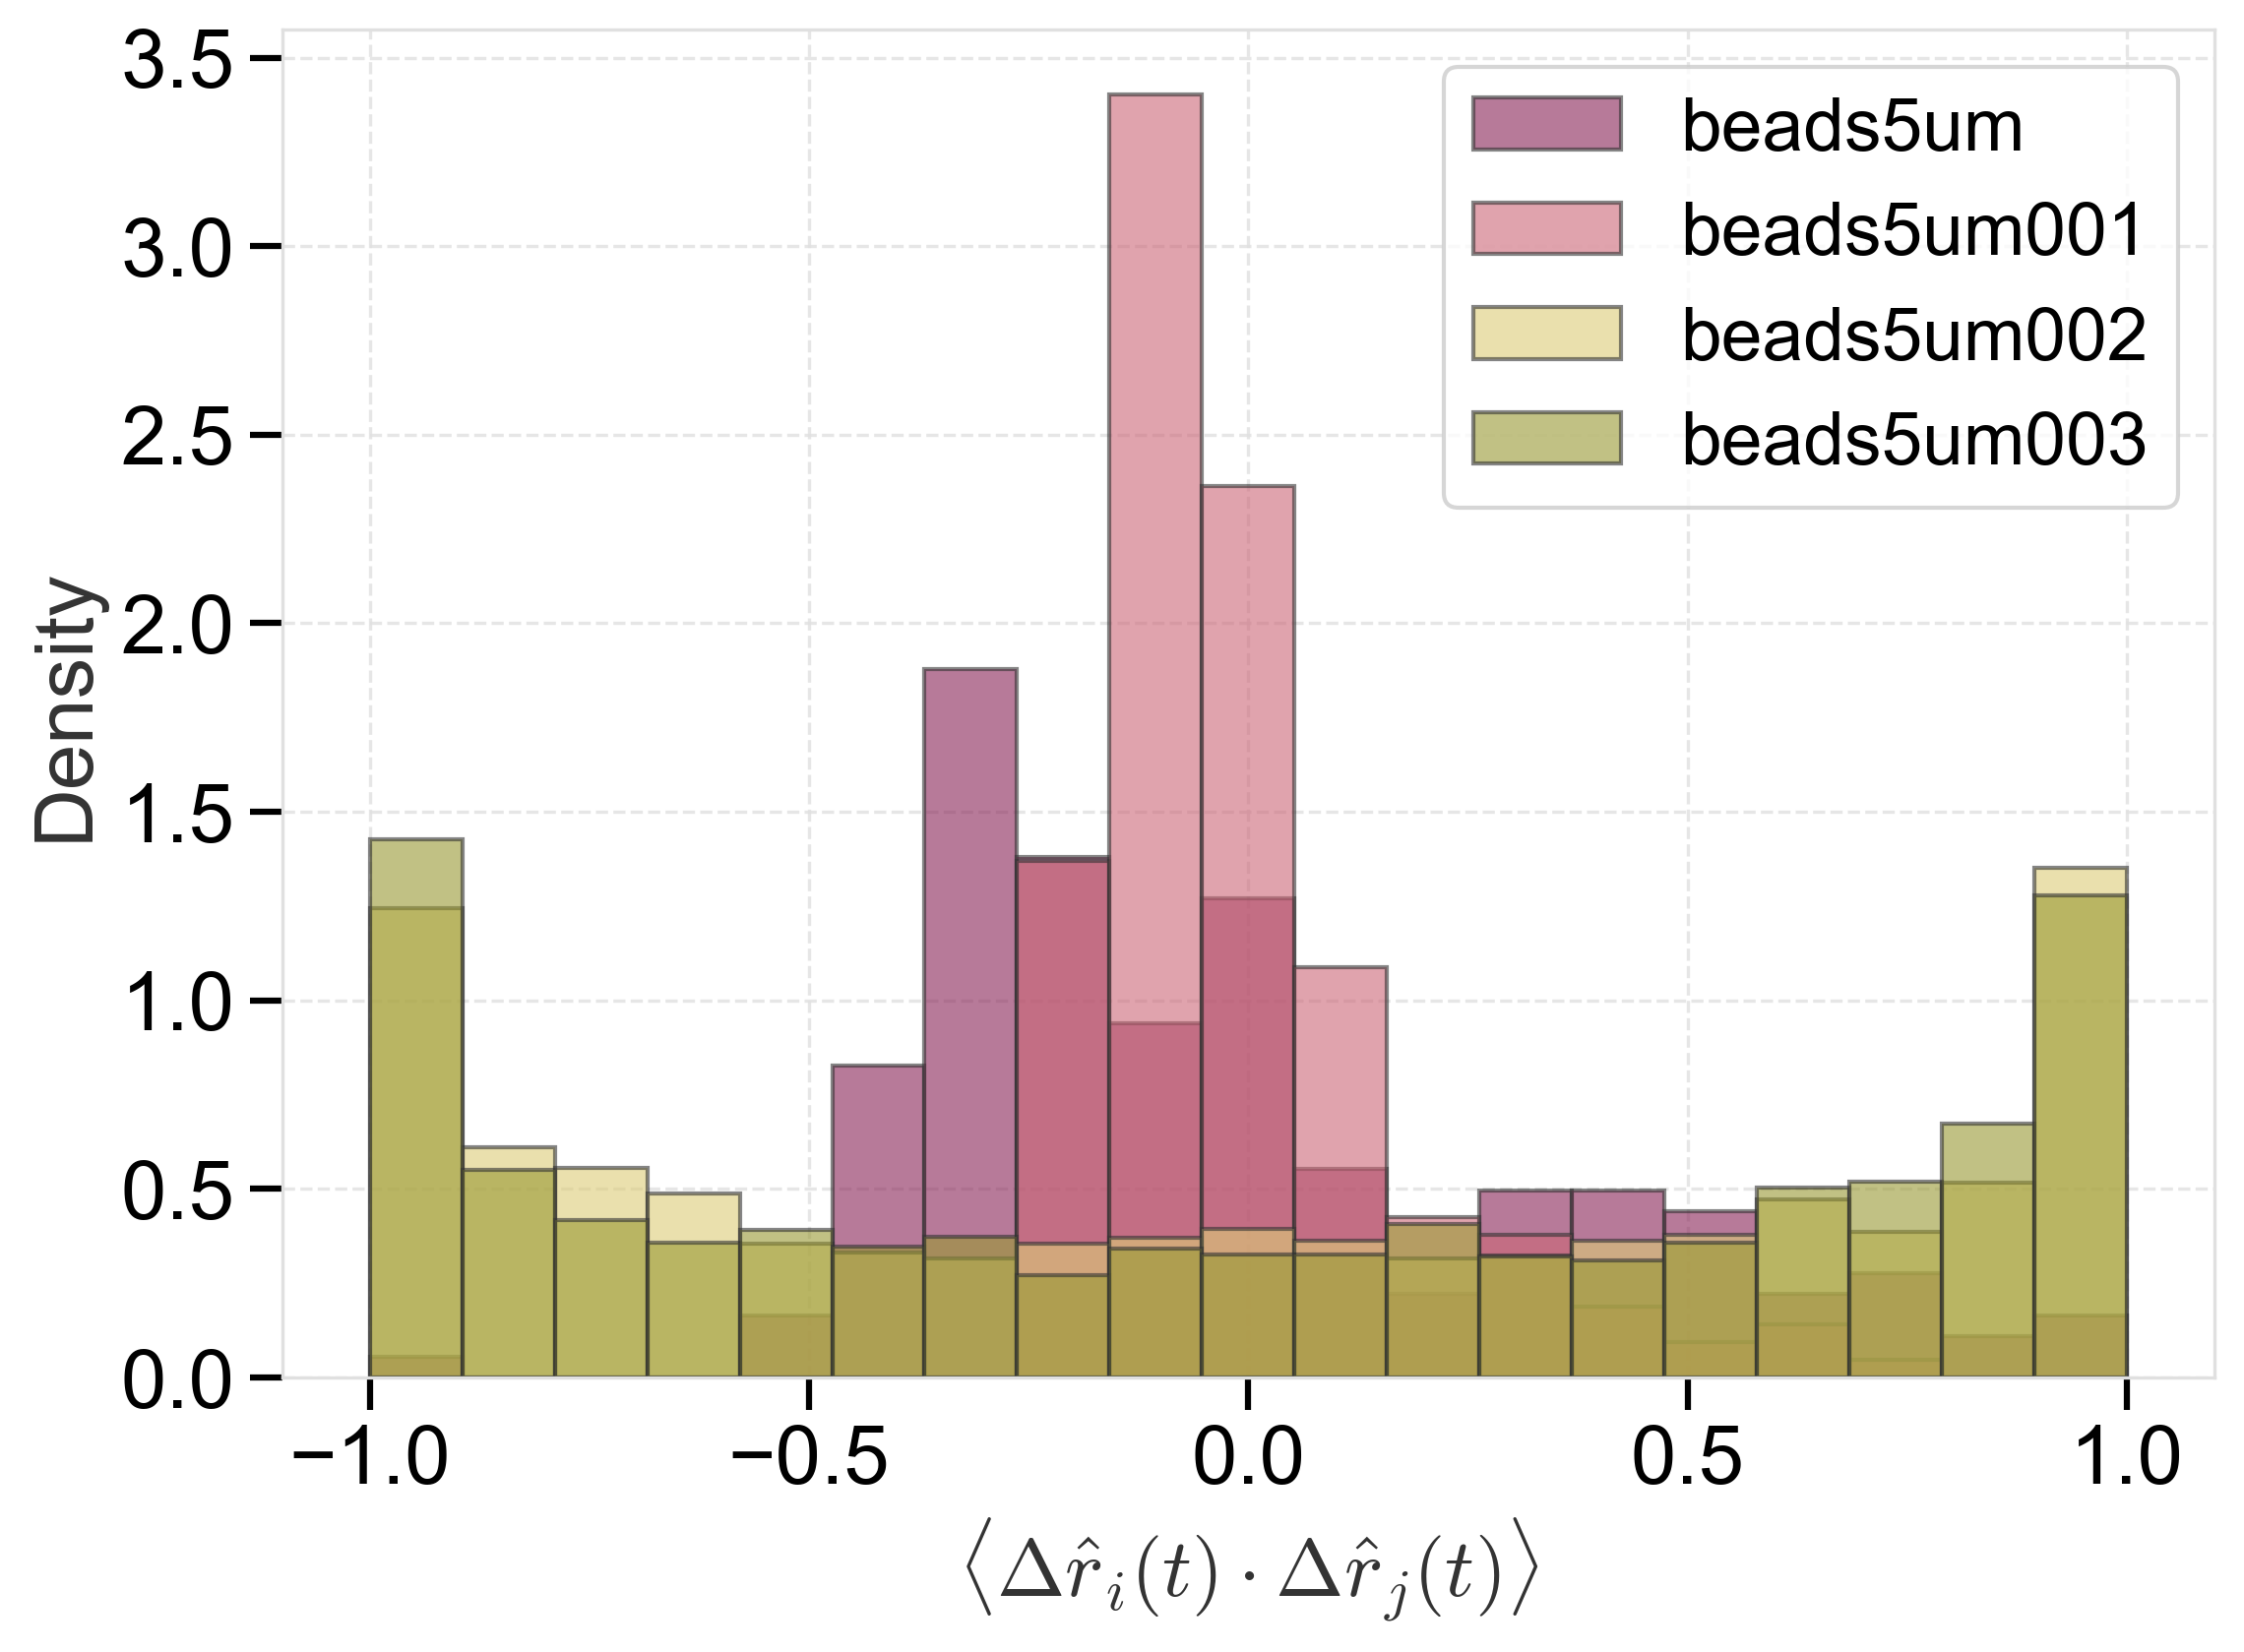

In [13]:
fig, ax = plt.subplots()

bins = np.linspace(-1,1, 20)

for exp, i in corr5.groupby('exp'):
    ax.hist(i['corr'], bins, label=exp, alpha =0.6, density = True, edgecolor ='#333333')

ax.legend()
ax.set(xlabel = "$\\langle \\Delta\\hat{r}_i(t) \cdot \\Delta\\hat{r}_j(t) \\rangle$", ylabel='Density')

fig.savefig(mypass/'figure'/'corr_beads5um.svg')

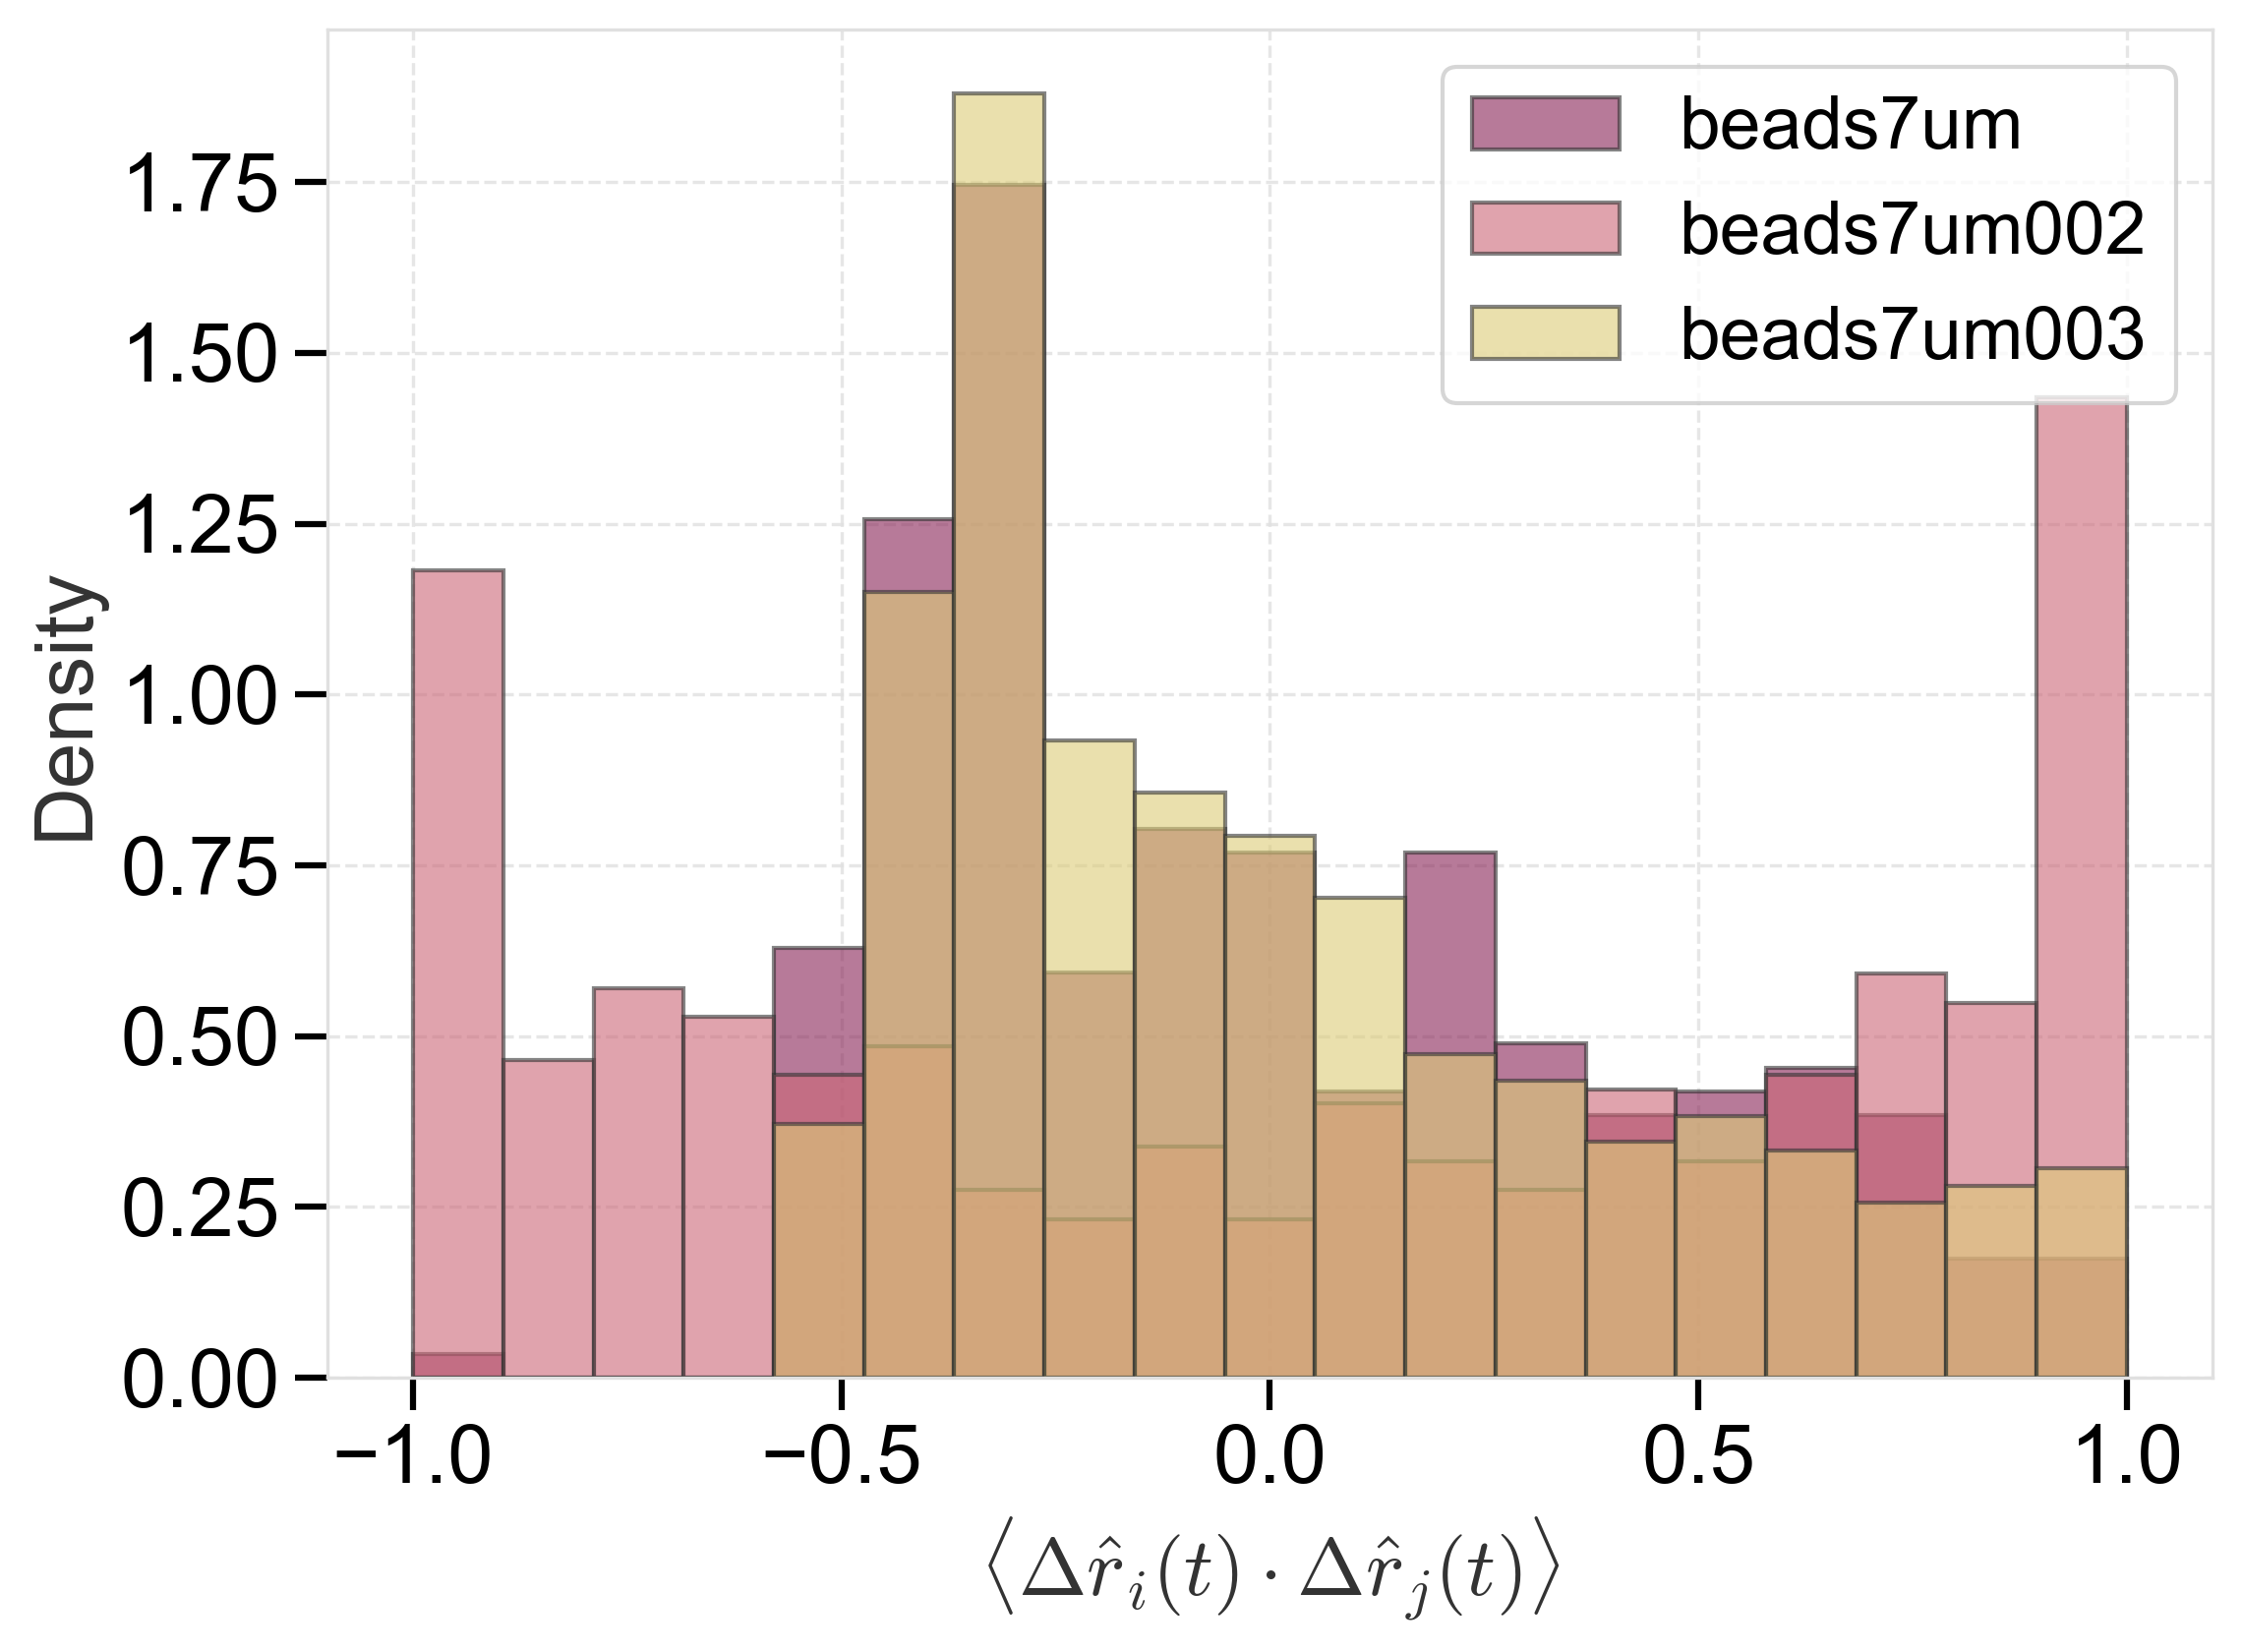

In [14]:
fig, ax = plt.subplots()

bins = np.linspace(-1,1, 20)

for exp, i in corr7.groupby('exp'):
    ax.hist(i['corr'], bins, label=exp, alpha =0.6, density = True, edgecolor ='#333333')

ax.legend()
ax.set(xlabel = "$\\langle \\Delta\\hat{r}_i(t) \cdot \\Delta\\hat{r}_j(t) \\rangle$", ylabel='Density')

fig.savefig(mypass/'figure'/'corr_beads7um.svg')